In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Carregando os dados

In [4]:
# Carregar os dados

df = pd.read_csv('dataset.csv')

(500, 2)

In [7]:
# Tamanho do dataframe ( 500 linhas e 2 colunas)

df.shape

(500, 2)

In [8]:
# Exibir colunas

df.columns

Index(['horas_estudo_mes', 'salario'], dtype='object')

In [9]:
# Inicio da tabela

df.head()

,horas_estudo_mes,salario
0,57.0,6813.0
1,48.0,6855.0
2,60.0,5801.0
3,73.0,7431.0
4,46.0,5475.0


In [10]:
# Informações do dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   horas_estudo_mes  500 non-null    float64
 1   salario           500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


### Análise Exploratória - Resumo Estatístico

In [11]:
# Verificar se há valores ausentes

df.isnull().sum()

horas_estudo_mes    0
salario             0
dtype: int64

In [12]:
# Correlação (-1 a +1)
# Próximo de +1 -> correlação positiva
# Próximo de -1 -> correlaçção negativa
# Próximo de 0  -> não há correlação

df.corr()

,horas_estudo_mes,salario
horas_estudo_mes,1.000000,0.818576
salario,0.818576,1.000000


Na correlação acima (0.818576), existe uma forte correlção entre a duas variáveis, isso é bom,
eu quero que a variável preditora (horas_estudo) ajude a explicar a variável alvo (salário).

Se, por acaso, não houver correlação, isto é, próximo de 0, é improvável a criação de um modelo.

O que queremos é uma alta correlação entre a variável de entrada (horas_estudo) e a variável de saída (salário).

Variável alvo -> aquilo que você quer prever. No nosso caso, o salário
Variável preditora(s) -> tenha uma boa correlação com a variável alvo. 

Se tiver mais de uma variável preditora, temos que tomar cuidado com outro possível problema, MULTICOLINERARIDADE.
Não é bom (não queremos) uma forte correlação entre variáveis preditoras.



In [14]:
# Resumo estatístico do dataset

df.describe()

,horas_estudo_mes,salario
count,500.000000,500.000000
mean,50.060000,6018.930000
std,14.659406,848.697853
min,1.000000,3664.000000
25%,39.750000,5473.000000
50%,50.000000,6013.500000
75%,60.000000,6542.000000
max,100.000000,9348.000000


In [16]:
# Resumo estatístico da variável preditora
df["horas_estudo_mes"].describe()

count    500.000000
mean      50.060000
std       14.659406
min        1.000000
25%       39.750000
50%       50.000000
75%       60.000000
max      100.000000
Name: horas_estudo_mes, dtype: float64

<Axes: xlabel='horas_estudo_mes', ylabel='Count'>

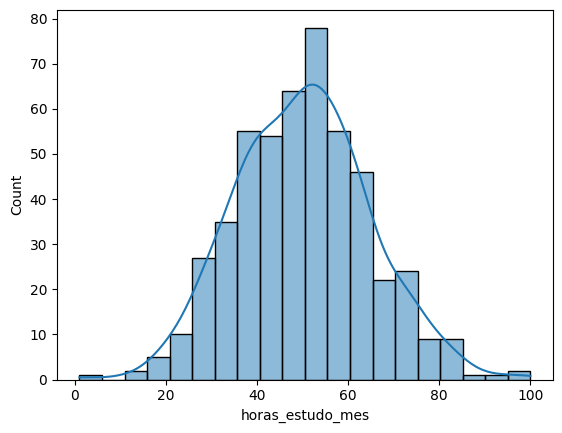

In [19]:
# Histograma da vriável preditora (organização)

sns.histplot(data = df, x = "horas_estudo_mes", kde = True)

A variável tem que ter o comportamento acima, senão, teremos que fazer outras checagens, aplicar alguns tratamentos ou transformaçãoes, para então preparar cada variável de entrada, para poder construir o modelo preditivo

### Preparação dos Dados

In [20]:
# Preparar a variável de entrada X

X = np.array(df['horas_estudo_mes'])

In [21]:
type(X)

numpy.ndarray

Para colocar no formato que o Scikit_learn espera receber, termos que fazer um ajuste no shape

In [22]:
# Ajustar o shape de X

X = X.reshape(-1, 1)

In [24]:
# Preparar a variável alvo Y

Y = df['salario']

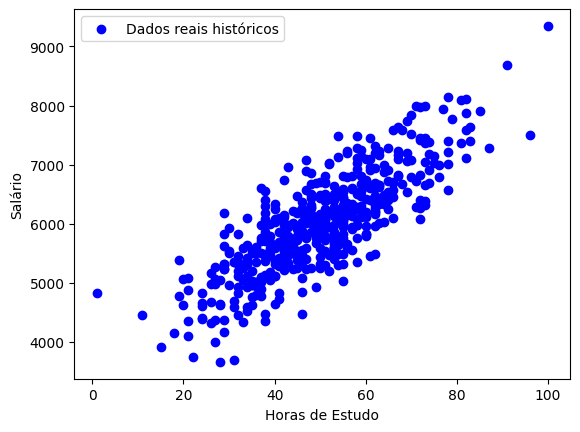

In [28]:
# Gráfico de dispersão entre X e Y
plt.scatter(X, Y, color = 'blue', label = "Dados reais históricos")
plt.xlabel("Horas de Estudo")
plt.ylabel('Salário')
plt.legend()
plt.show()

Existe uma correlação positiva entrea duas varáveis. Quanto mais tempo a pessoa estuda, maior é o seu salário. 

Não podemos afirmar que o salário aumenta SÓ POR CAUSA da horas de estudo. Não posso tirar qualquer conclusão sobre "causalidade"

In [29]:
# Dividir dados em treinamento e teste | Técnica de estatística de amostragem

X_treino, X_teste, Y_treino, Y_teste, = train_test_split(X, Y, test_size = 0.2, random_state = 42) 

In [30]:
X_treino.shape

(400, 1)

In [31]:
X_teste.shape

(100, 1)

In [33]:
Y_treino.shape

(400,)

In [34]:
Y_teste.shape

(100,)

### Modelagem Preditiva (Machine Learning)

In [35]:
# Cria o modelo de regressão linear simples

modelo = LinearRegression()

In [36]:
# Treina o modelo

modelo.fit(X_treino, Y_treino)

LinearRegression()

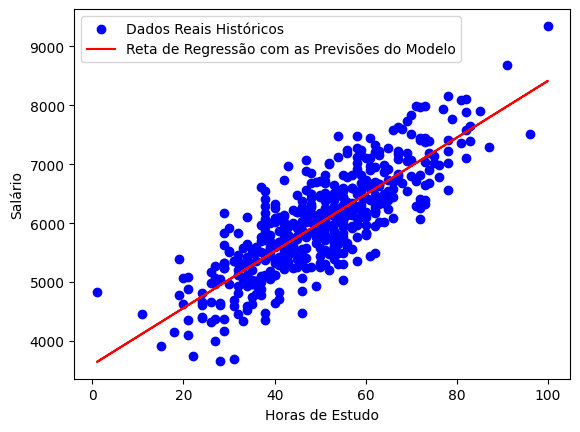

In [38]:
# Visualiza a reta de regressão linear (previsões) e os dados reais usados no treinamento
plt.scatter(X, Y, color = "blue", label = "Dados Reais Históricos")
plt.plot(X, modelo.predict(X), color = "red", label = "Reta de Regressão com as Previsões do Modelo")
plt.xlabel("Horas de Estudo")
plt.ylabel("Salário")
plt.legend()
plt.show()

In [39]:
# Avalia o modelo nos dados de teste
score = modelo.score(X_teste, Y_teste)
print(f"Coeficiente R^2: {score:.2f}")

Coeficiente R^2: 0.59


O coeficiente acima é razoavel

In [40]:
# Intercepto - paâmetro w0

modelo.intercept_

3596.7837243727527

In [41]:
# Slope - parâmetro w1

modelo.coef_


array([48.18185277])

Algoritmo de Regressão Linear:

![DSA](imagens/reglinear.png)

### Deploy do Modelo | Entregar o modelo

O trabalho do Cientista de dados termina no modelo.

O deploy geralmente é tarefa do engenheiro de machine learning.

In [53]:
# Define um novo valor para horas de estudo
horas_estudo_novo = np.array([[48]]) 

# Faz previsão com o modelo treinado
salario_previsto = modelo.predict(horas_estudo_novo)

print(f"Se você estudar cerca de", horas_estudo_novo, "horas por mês seu salário pode ser igual a", salario_previsto)

Se você estudar cerca de [[48]] horas por mês seu salário pode ser igual a [5909.5126574]


In [54]:
# Mesmo resultado anterior usando os parâmetros (coeficientes) aprendidos pelo modelo
# y_novo = w0 + w1 * X
salario = modelo.intercept_ + (modelo.coef_ * horas_estudo_novo)
print(salario)

[[5909.5126574]]


In [55]:
# Define um novo valor para horas de estudo
horas_estudo_novo = np.array([[65]]) 

# Faz previsão com o modelo treinado
salario_previsto = modelo.predict(horas_estudo_novo)

print(f"Se você estudar cerca de", horas_estudo_novo, "horas por mês seu salário pode ser igual a", salario_previsto)

Se você estudar cerca de [[65]] horas por mês seu salário pode ser igual a [6728.60415452]


In [56]:
# Define um novo valor para horas de estudo
horas_estudo_novo = np.array([[73]]) 

# Faz previsão com o modelo treinado
salario_previsto = modelo.predict(horas_estudo_novo)

print(f"Se você estudar cerca de", horas_estudo_novo, "horas por mês seu salário pode ser igual a", salario_previsto)

Se você estudar cerca de [[73]] horas por mês seu salário pode ser igual a [7114.05897669]
